## Linear regression by using Deep Neural network: 
Implement Boston housing price 
prediction problem by Linear regression using Deep Neural network. Use Boston House 
price prediction dataset. 

In [55]:
import pandas as pd

In [56]:
df = pd.read_csv("../DL/Assignment01/HousingData.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [58]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [59]:
def remove_null_entries(df):
    for col in df.columns:
        mean = df[col].mean()
        df[col] = df[col].fillna(mean)
    return df

df = remove_null_entries(df)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [60]:
import seaborn as sns

<Axes: ylabel='MEDV'>

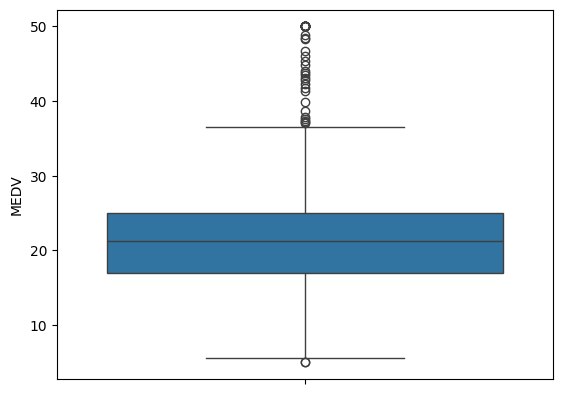

In [61]:
sns.boxplot(y=df["MEDV"])

In [62]:
def remove_outliers(df, col):
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    IQR = q3 - q1
    ll  = q1 - 1.5*IQR
    ul  = q3 + 1.5*IQR
    df = df[(df[col] >= ll) & (df[col]<=ul)]
    return df

df = remove_outliers(df, col="MEDV")
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000,466.000000
mean,3.586269,10.367628,11.325128,0.060942,0.556826,6.179633,68.731362,3.833586,9.669528,413.105150,18.617382,354.197790,13.303965,20.719099
std,8.183586,21.722403,6.619018,0.233566,0.117400,0.576325,27.336403,2.124901,8.792361,168.544572,2.063273,94.679607,6.814424,6.451416
min,0.006320,0.000000,0.740000,0.000000,0.385000,3.561000,2.900000,1.137000,1.000000,187.000000,12.600000,0.320000,1.980000,5.600000
25%,0.085120,0.000000,5.860000,0.000000,0.453000,5.876250,46.400000,2.104425,4.000000,284.000000,17.400000,374.590000,7.927500,16.500000
50%,0.274475,0.000000,9.955000,0.000000,0.538000,6.163500,74.650000,3.272100,5.000000,335.000000,19.100000,391.955000,12.670000,20.600000
75%,3.611874,11.211934,18.100000,0.000000,0.624000,6.506250,93.750000,5.241300,24.000000,666.000000,20.200000,396.397500,17.107500,24.075000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,36.500000


<Axes: ylabel='MEDV'>

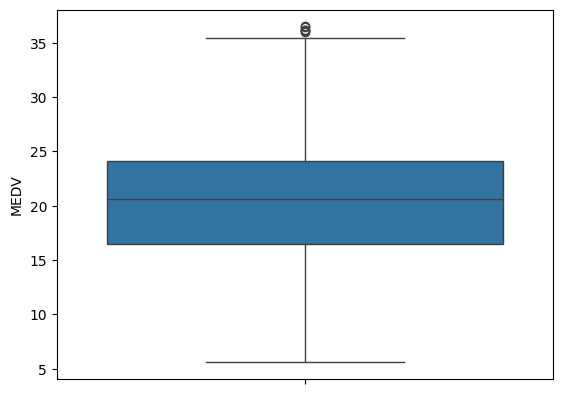

In [63]:
sns.boxplot(y=df["MEDV"])

In [64]:
X = df.drop(labels=["MEDV"], axis=1)
y = df["MEDV"]

In [65]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [66]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test  = scalar.fit_transform(X_test)

X_train

array([[-0.41724809, -0.47961487, -0.0581163 , ..., -0.98850897,
         0.41690627, -0.41997431],
       [-0.35691576, -0.47961487, -0.49703771, ...,  1.17048907,
         0.23510485,  0.18755323],
       [-0.41396998,  0.1175285 , -0.53729217, ..., -1.55172585,
         0.45098056,  0.7993095 ],
       ...,
       [ 2.2095172 , -0.47961487,  0.98790437, ...,  0.79501115,
         0.45098056,  2.08625299],
       [ 0.26205271, -0.47961487,  0.98790437, ...,  0.79501115,
        -0.5641313 ,  1.49704995],
       [-0.41450552, -0.47961487, -0.43441967, ...,  1.12355433,
         0.40558412, -0.16202178]], shape=(326, 13))

In [67]:
from tensorflow.keras.layers import Dense, Layer
from tensorflow.keras.models import Sequential

model = Sequential()

# Define layers
layer1 = Dense(128, input_shape=(13,), activation='relu', name='dense_1')

layer2 = Dense(64, activation='relu', name='dense_2')

layer3 = Dense(1, activation='linear', name='output_dense')

model.add(layer1)
model.add(layer2)
model.add(layer3)

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

c:\Users\LENOVO\Desktop\BE-Lab-Assignments\LP-V\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,113 (39.50 KB)

 Trainable params: 10,113 (39.50 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_split=0.05,
    verbose=1
)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 463.0208 - mae: 20.4431 - val_loss: 352.3447 - val_mae: 17.6437
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 409.7267 - mae: 19.0284 - val_loss: 300.3350 - val_mae: 16.0530
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 341.9182 - mae: 17.1349 - val_loss: 235.9444 - val_mae: 13.8509
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 258.6995 - mae: 14.6064 - val_loss: 163.5946 - val_mae: 11.1379
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 167.0995 - mae: 11.4417 - val_loss: 96.2633 - val_mae: 8.3448
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 87.7477 - mae: 7.9940 - val_loss: 51.6618 - val_mae: 6.0771
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 50.9988 - mae: 5.9301 - val_loss: 34.7545 - val_mae: 4.5183
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 39.9631 - mae: 5.1242 - val_loss: 23.9105 - val_mae: 3.6248
Epoch 9/100
10/10 ━━━━━━━━━━━

In [69]:
mse, mae = model.evaluate(X_test, y_test)
print("Mean Squared Error : ", mse)
print("Mean Absolute Error : ", mae)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.7313 - mae: 2.2963 
Mean Squared Error :  8.731304168701172
Mean Absolute Error :  2.2962520122528076
